# Predictive Income Analysis: Socioeconomic Level Classification Based on Census Data.

* Objective: To predict whether a person exceeds the $50,000 annual income
threshold.

* Value: This type of model helps marketing companies or financial services to segment customers.

# 1. Data ingestion and initial inspection  



In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick


We work first with the training dataset.

In [ ]:
df = pd.read_csv('/content/sample_data/train.csv')

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
index,27656.0,16274.894851,9410.041750,0.0,8104.75,16296.0,24431.25,32559.0
age,27656.0,38.610356,13.659928,17.0,28.00,37.0,48.00,90.0
education.num,27656.0,10.093506,2.566083,1.0,9.00,10.0,12.00,16.0
capital.gain,27656.0,1099.991503,7487.323462,0.0,0.00,0.0,0.00,99999.0
capital.loss,27656.0,88.284387,405.821328,0.0,0.00,0.0,0.00,4356.0
hours.per.week,27656.0,40.446666,12.369212,1.0,40.00,40.0,45.00,99.0
ID,27656.0,16267.565736,9403.092602,0.0,8104.75,16291.0,24416.25,32535.0


Dataset Variables:

* Age: Describes the age of individuals. Continuous.
* Workclass: Private, Self-emp-not-inc, Self-emp-inc, Federal-gov, Local-gov, State-gov, Without-pay, Never-worked.
fnlwgt: Continuous.
* education: Bachelors, Some-college, 11th, HS-grad, Prof-school, Assoc-acdm, Assoc-voc, 9th, 7th-8th, 12th, Masters, 1st-4th, 10th, Doctorate, 5th-6th, Preschool.
* education-num: Number of years spent in education. Continuous.
* marital-status: Married-civ-spouse, Divorced, Never-married, Separated, Widowed, Married-spouse-absent, Married-AF-spouse.
* occupation: Tech-support, Craft-repair, Other-service, Sales, Exec-managerial, Prof-specialty, Handlers-cleaners, Machine-op-inspct, Adm-clerical, Farming-fishing, Transport-moving, Priv-house-serv, Protective-serv, Armed-Forces.
* relationship: Wife, Own-child, Husband, Not-in-family, Other-relative, Unmarried.
* race: White, Asian-Pac-Islander, Amer-Indian-Eskimo, Other, Black.
* sex: Female, Male.
* capital-gain: Continuous.
* capital-loss: Continuous.
* hours-per-week: Continuous.
* native-country: United-States, Cambodia, England, Puerto-Rico, Canada, Germany, Outlying-US(Guam-USVI-etc), India, Japan, Greece, South, China, Cuba, Iran, Honduras, Philippines, Italy, Poland, Jamaica, Vietnam, Mexico, Portugal, Ireland, France, Dominican-Republic, Laos, Ecuador, Taiwan, Haiti, Columbia, Hungary, Guatemala, Nicaragua, Scotland, Thailand, Yugoslavia, El-Salvador, Trinadad&Tobago, Peru, Hong, Holand-Netherlands.

* salary: >50K,<=50K



# 2. Exploratory Data Analysis (EDA)  

Before modeling, an exploratory analysis was conducted to understand the structure
and quality of the data. The EDA focused on:

- Identification of hidden missing values (`?`)
- Analysis of target and predictor variables
- Cardinality challenges in categorical features

### Handling Missing Values


In [ ]:
df.isnull().sum()

,0
index,0
age,0
workclass,0
education,0
education.num,0
marital.status,0
occupation,0
relationship,0
race,0
sex,0


In [ ]:
print((df == '?').sum())

index                0
age                  0
workclass         1539
education            0
education.num        0
marital.status       0
occupation        1546
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     504
income               0
ID                   0
dtype: int64


Hidden missing values represented approximately 7% of the dataset.
Instead of removing these observations, they were grouped into a new
category labeled **"Unknown"**.

**Rationale:**
- Removing a significant portion of the data could introduce bias
- In real-world scenarios, unknown values are common and must be handled
- Missingness itself may carry predictive information (Missing Not At Random)

We replace '?' with 'Unknown' throughout the dataset

In [ ]:
df.replace('?', 'Unknown', inplace=True)
print((df == '?').sum())

index             0
age               0
workclass         0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
ID                0
dtype: int64


## Target 'Income' analysis

In [ ]:
df['income_binary'] = df['income'].apply(lambda x: 1 if '>50K' in x else 0)

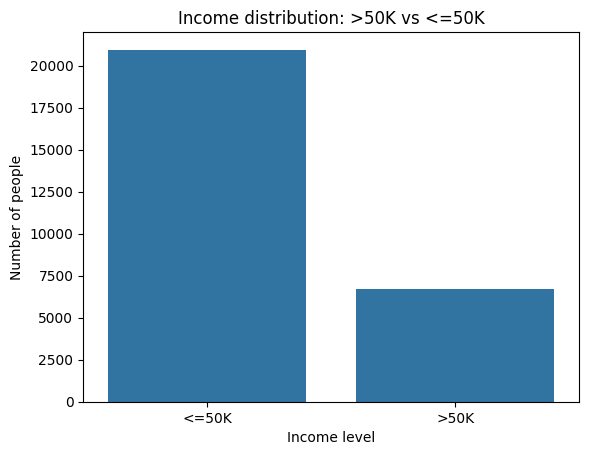

In [ ]:
sns.countplot(data=df, x='income_binary')
plt.title('Income distribution: >50K vs <=50K')
plt.xlabel('Income level')
plt.ylabel('Number of people')
plt.xticks(ticks=[0, 1], labels=['<=50K', '>50K'])
plt.show()

In [ ]:
proporción_target = df['income'].value_counts(normalize=True)

print(f'Proportion of the target classes: \n {proporción_target *100}:')

Proportion of the target classes: 
 income
<=50K    75.762945
>50K     24.237055
Name: proportion, dtype: float64:


**Class Imbalance**

The target variable shows a class distribution of approximately 75.7% (<=50K)
and 24.3% (>50K). Although the dataset is imbalanced, the minority class
contains a sufficient number of observations for effective model training.

The original class distribution was preserved to maintain data integrity.


## Predictive Variables and Outliers:

An analysis of the predictor variables was performed to understand their
distribution, relationships with the target variable, and potential impact
on model performance.



In [ ]:
object_cols = df.select_dtypes(include='object').columns
object_nunique = list(map(lambda col: df[col].nunique(), object_cols))
d = dict(zip(object_cols, object_nunique))
sorted(d.items(), key=lambda x: x[1])

[('sex', 2),
 ('income', 2),
 ('race', 5),
 ('relationship', 6),
 ('marital.status', 7),
 ('workclass', 9),
 ('occupation', 15),
 ('education', 16),
 ('native.country', 42)]

/tmp/ipykernel_15170/2110575091.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0,0].set_xticklabels(ax[0,0].get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_15170/2110575091.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0,1].set_xticklabels(ax[0,1].get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_15170/2110575091.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1,0].set_xticklabels(ax[1,0].get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_15170/2110575091.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1,1].set_xticklabels(ax[1,1].get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_15170/

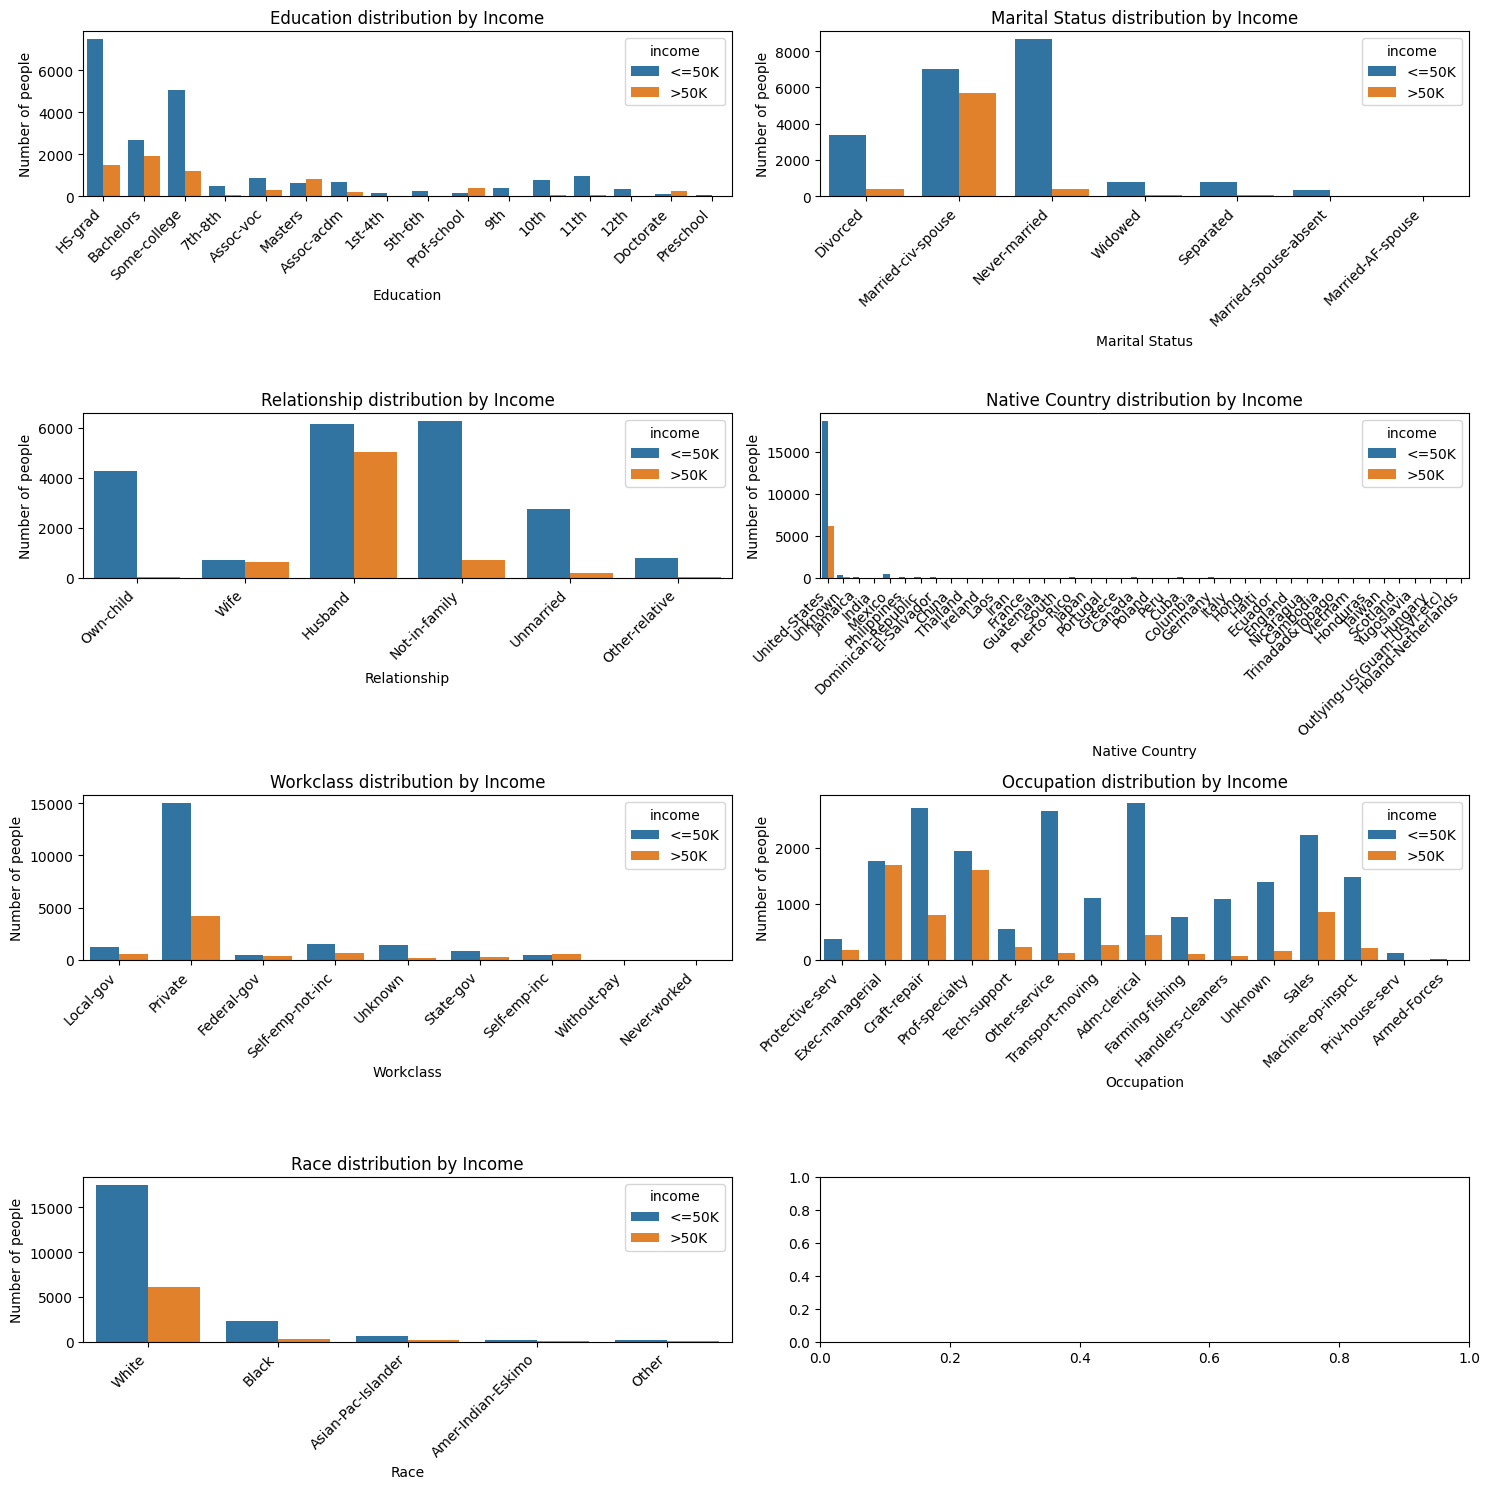

In [ ]:
fig, ax = plt.subplots(nrows=4, ncols=2, figsize=(15, 15))

# education
ax[0,0].set_title('Education distribution by Income')
sns.countplot(data=df, x='education', hue='income', ax=ax[0,0])
ax[0,0].set_xlabel('Education')
ax[0,0].set_ylabel('Number of people')
ax[0,0].set_xticklabels(ax[0,0].get_xticklabels(), rotation=45, ha='right')
# marital status
ax[0,1].set_title('Marital Status distribution by Income')
sns.countplot(data=df, x='marital.status', hue='income', ax=ax[0,1])
ax[0,1].set_xlabel('Marital Status')
ax[0,1].set_ylabel('Number of people')
ax[0,1].set_xticklabels(ax[0,1].get_xticklabels(), rotation=45, ha='right')
#relationship
ax[1,0].set_title('Relationship distribution by Income')
sns.countplot(data=df, x='relationship', hue='income', ax=ax[1,0])
ax[1,0].set_xlabel('Relationship')
ax[1,0].set_ylabel('Number of people')
ax[1,0].set_xticklabels(ax[1,0].get_xticklabels(), rotation=45, ha='right')
#native.country
ax[1,1].set_title('Native Country distribution by Income')
sns.countplot(data=df, x='native.country', hue='income', ax=ax[1,1])
ax[1,1].set_xlabel('Native Country')
ax[1,1].set_ylabel('Number of people')
ax[1,1].set_xticklabels(ax[1,1].get_xticklabels(), rotation=45, ha='right')
# workclass
ax[2,0].set_title('Workclass distribution by Income')
sns.countplot(data=df, x='workclass', hue='income', ax=ax[2,0])
ax[2,0].set_xlabel('Workclass')
ax[2,0].set_ylabel('Number of people')
ax[2,0].set_xticklabels(ax[2,0].get_xticklabels(), rotation=45, ha='right')
#occupation
ax[2,1].set_title('Occupation distribution by Income')
sns.countplot(data=df, x='occupation', hue='income', ax=ax[2,1])
ax[2,1].set_xlabel('Occupation')
ax[2,1].set_ylabel('Number of people')
ax[2,1].set_xticklabels(ax[2,1].get_xticklabels(), rotation=45, ha='right')
#race
ax[3,0].set_title('Race distribution by Income')
sns.countplot(data=df, x='race', hue='income', ax=ax[3,0])
ax[3,0].set_xlabel('Race')
ax[3,0].set_ylabel('Number of people')
ax[3,0].set_xticklabels(ax[3,0].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

**Key Observations**

- Strong imbalance is observed in variables such as `native.country` and `race`.

- The variables `occupation` and `workclass` show high category dispersion,
  suggesting the need for category consolidation to reduce the risk of
  model overfitting.

----

**Outliers**

Outliers were identified and analyzed to assess whether they represent data
errors or valid extreme observations. Given the nature of the dataset, most
outliers were considered plausible and were retained to preserve real-world
variability.

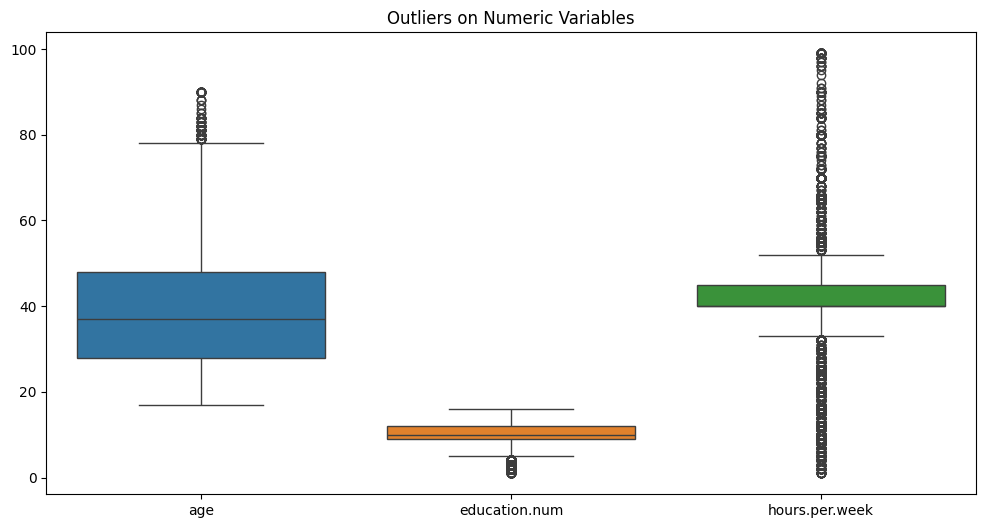

People with maximum capital gain: 139


In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[['age', 'education.num', 'hours.per.week']])
plt.title("Outliers on Numeric Variables")
plt.show()

print("People with maximum capital gain:", len(df[df['capital.gain'] == 99999]))

# Preprocessing Overview

The preprocessing steps were designed to ensure data quality, reduce
dimensionality, and prevent data leakage. Key steps included:

- Cardinality reduction through category consolidation
- Encoding of categorical variables
- Train-test split with stratification
- Feature scaling for model compatibility


## Categorical Cardinality Reduction (Feature Engineering)

Reducing cardinality in categorical variables is a key step to mitigate the
curse of dimensionality. High-cardinality features increase data sparsity,
which can negatively affect model generalization.

### Grouping Strategy

Categories with similar behavior with respect to the target variable were
consolidated under the assumption that they retain similar predictive value.

Two criteria were used to guide the grouping process:

- **Proportion Analysis:** Visualization of the >50K income rate by category
  to identify macro-level trends.
- **Statistical Overlap Criterion:** Confidence intervals (CI) for the success
  proportion of each category were computed. Categories with significant CI
  overlap were grouped, assuming statistically indistinguishable behavior.

This approach results in a more parsimonious model and reduces the risk of
overfitting in low-frequency categories.

Each variable in the notebook follows the workflow:
**Analysis → Implementation → Validation**.




## 'Education'

### Dimensionality optimization

The variable `education` was found to have a one-to-one correspondence with
`education.num`. Since education level is ordinal in nature, only the numeric
variable was retained.

This allows the model to capture academic hierarchy linearly in a single
dimension, avoiding the sparsity introduced by one-hot encoding the original
16 categorical levels, while preserving predictive signal.

In [ ]:
df_poreduc = df.groupby('education')['education.num'].mean()
print(df_poreduc)

education
10th             6.0
11th             7.0
12th             8.0
1st-4th          2.0
5th-6th          3.0
7th-8th          4.0
9th              5.0
Assoc-acdm      12.0
Assoc-voc       11.0
Bachelors       13.0
Doctorate       16.0
HS-grad          9.0
Masters         14.0
Preschool        1.0
Prof-school     15.0
Some-college    10.0
Name: education.num, dtype: float64


In [ ]:
# Verify the bijective relationship before deleting
print(df.groupby('education')['education.num'].unique().sort_values())

# Elimination of the redundant column
df.drop('education', axis=1, inplace=True)

education
Preschool        [1]
1st-4th          [2]
5th-6th          [3]
7th-8th          [4]
9th              [5]
10th             [6]
11th             [7]
12th             [8]
HS-grad          [9]
Some-college    [10]
Assoc-voc       [11]
Assoc-acdm      [12]
Bachelors       [13]
Masters         [14]
Prof-school     [15]
Doctorate       [16]
Name: education.num, dtype: object


## 'Marital status'

### Marital Status Consolidation

Based on confidence interval analysis for the proportion of individuals earning >50K, the original marital status categories were consolidated into two groups:

- **Married (High Proportion):** `Married-civ-spouse`, `Married-AF-spouse`
- **Alone (Low Proportion):** `Never-married`, `Divorced`, `Separated`,
  `Widowed`, `Married-spouse-absent`

Categories within each group showed overlapping confidence intervals, indicating
statistically similar behavior. This consolidation reduces noise while capturing
the strong predictive signal associated with marital stability.

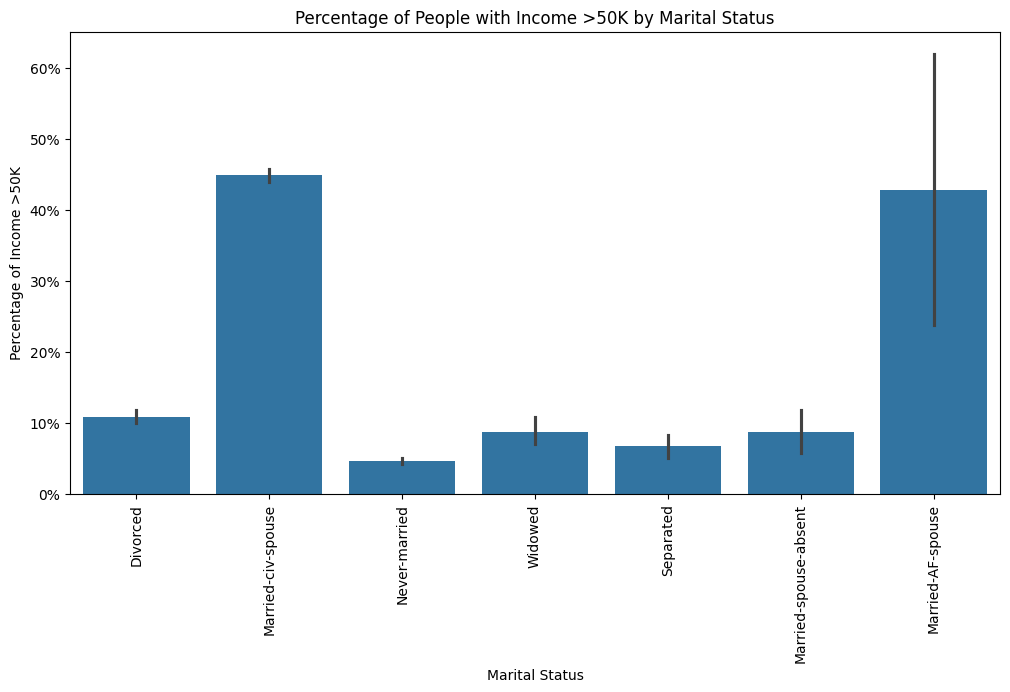

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(x='marital.status', y='income_binary', data=df, errorbar=('ci', 95))
plt.xticks(rotation=90)
plt.title('Percentage of People with Income >50K by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Percentage of Income >50K')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

In [ ]:
# We group and compute the mean (p) and the sample size (n)
stats = df.groupby('marital.status')['income_binary'].agg(['mean', 'count']).copy()

# We calculate the Standard Error (SE) for proportions
stats['se'] = np.sqrt(stats['mean'] * (1 - stats['mean']) / stats['count'])

# We calculate the interval limits at 95% (z = 1.96)
stats['lower_limit'] = stats['mean'] - 1.96 * stats['se']
stats['upper_limit'] = stats['mean'] + 1.96 * stats['se']

# We sort by the mean to view the hierarchy
stats = stats.sort_values('mean', ascending=False)

print(stats[['mean', 'lower_limit', 'upper_limit']])

                           mean  lower_limit  upper_limit
marital.status                                           
Married-civ-spouse     0.448899     0.440256     0.457543
Married-AF-spouse      0.428571     0.216911     0.640232
Divorced               0.108223     0.098306     0.118140
Widowed                0.087515     0.068595     0.106434
Married-spouse-absent  0.087432     0.058493     0.116371
Separated              0.066511     0.049828     0.083194
Never-married          0.045450     0.041162     0.049737


In [ ]:
def preprocess_marital_status(df):
    marital_mapping = {
        'Married-civ-spouse': 'Married',
        'Married-AF-spouse': 'Married',
        'Married-spouse-absent': 'Alone',
        'Never-married': 'Alone',
        'Divorced': 'Alone',
        'Widowed': 'Alone',
        'Separated': 'Alone'
    }

    df = df.copy()
    df['marital_grouped'] = df['marital.status'].map(marital_mapping)
    df.drop(columns='marital.status', inplace=True)

    return df

In [ ]:
df = preprocess_marital_status(df)

In [ ]:
#Verifying the new distribution
print(df['marital_grouped'].value_counts())

marital_grouped
Alone      14915
Married    12741
Name: count, dtype: int64


## 'Relationship'

### Relationship Consolidation

A similar confidence interval analysis was applied to the `relationship` variable,
resulting in two groups:

- **Partner (High Proportion):** `Husband`, `Wife`
- **Other (Low Proportion):** `Not-in-family`, `Unmarried`, `Other-relative`,
  `Own-child`

Despite minor differences within the low-proportion group, variability was small
relative to the separation from the `Partner` group. Grouping these categories
reduces sparsity and preserves the core predictive signal.

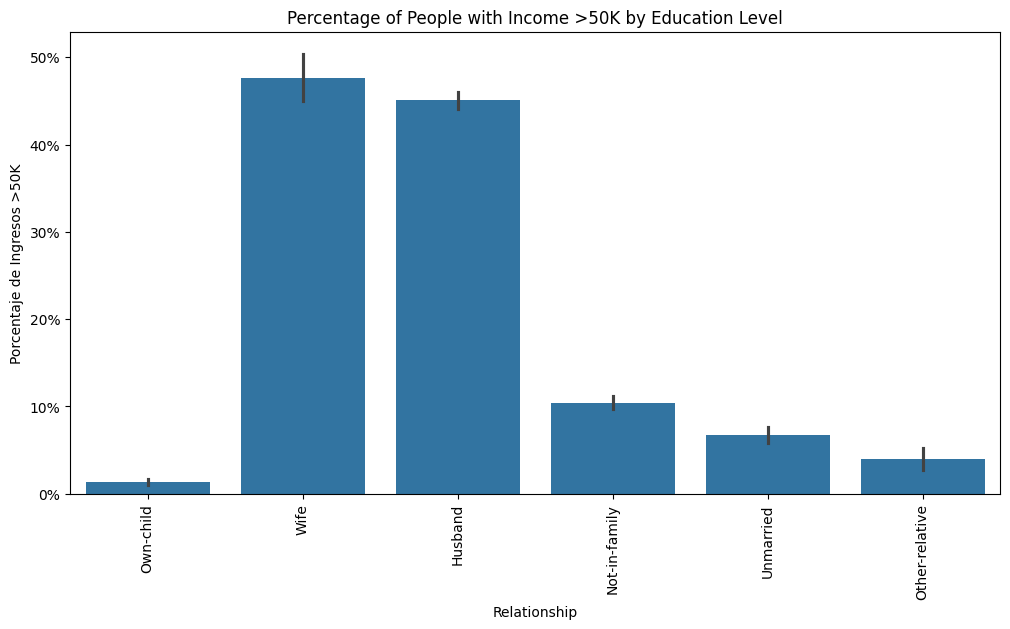

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(x='relationship', y='income_binary', data=df, errorbar=('ci', 95))
plt.xticks(rotation=90)
plt.title('Percentage of People with Income >50K by Education Level')
plt.xlabel('Relationship')
plt.ylabel('Porcentaje de Ingresos >50K')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
plt.show()

In [ ]:
stats = df.groupby('relationship')['income_binary'].agg(['mean', 'count']).copy()

stats['se'] = np.sqrt(stats['mean'] * (1 - stats['mean']) / stats['count'])

stats['lower_limit'] = stats['mean'] - 1.96 * stats['se']
stats['upper_limit'] = stats['mean'] + 1.96 * stats['se']

stats = stats.sort_values('mean', ascending=False)

print(stats[['mean', 'lower_limit', 'upper_limit']].map(lambda x: f"{x:.2%}"))

                  mean lower_limit upper_limit
relationship                                  
Wife            47.64%      44.96%      50.32%
Husband         45.07%      44.15%      46.00%
Not-in-family   10.38%       9.67%      11.10%
Unmarried        6.73%       5.82%       7.63%
Other-relative   3.94%       2.62%       5.26%
Own-child        1.34%       1.00%       1.68%


In [ ]:
def preprocess_relationship(df):

  relationship_mapping= {
    'Wife' : 'Partner',
    'Husband' : 'Partner',
    'Not-in-family' : 'Other',
    'Unmarried' : 'Other',
    'Other-relative' : 'Other',
    'Own-child' : 'Other'
}

  df = df.copy()
  df['relationship_grouped'] = df['relationship'].map(relationship_mapping)
  df.drop(columns='relationship', inplace=True)

  return df

In [ ]:
df = preprocess_relationship(df)
print(df['relationship_grouped'].value_counts())

relationship_grouped
Other      15115
Partner    12541
Name: count, dtype: int64


In [ ]:
print(df['relationship_grouped'].value_counts())

relationship_grouped
Other      15115
Partner    12541
Name: count, dtype: int64


## 'Native.country'

### Geographic Bias Handling

Analysis of the `native.country` variable revealed a strong concentration effect,
with the United States accounting for approximately 91% of observations.
Although some countries (e.g., India, Taiwan) show higher income rates, their
low representation (n < 100) results in wide confidence intervals, making these
estimates statistically unreliable.

To reduce overfitting risk and simplify the feature space, the variable was
binarized as follows:

- **US:** Dominant category providing the most stable signal
- **Other:** Consolidation of all remaining countries, treating foreign origin
  as a shared factor with sufficient sample size

This approach prevents the creation of numerous sparse dummy variables and
follows the principle of parsimony.

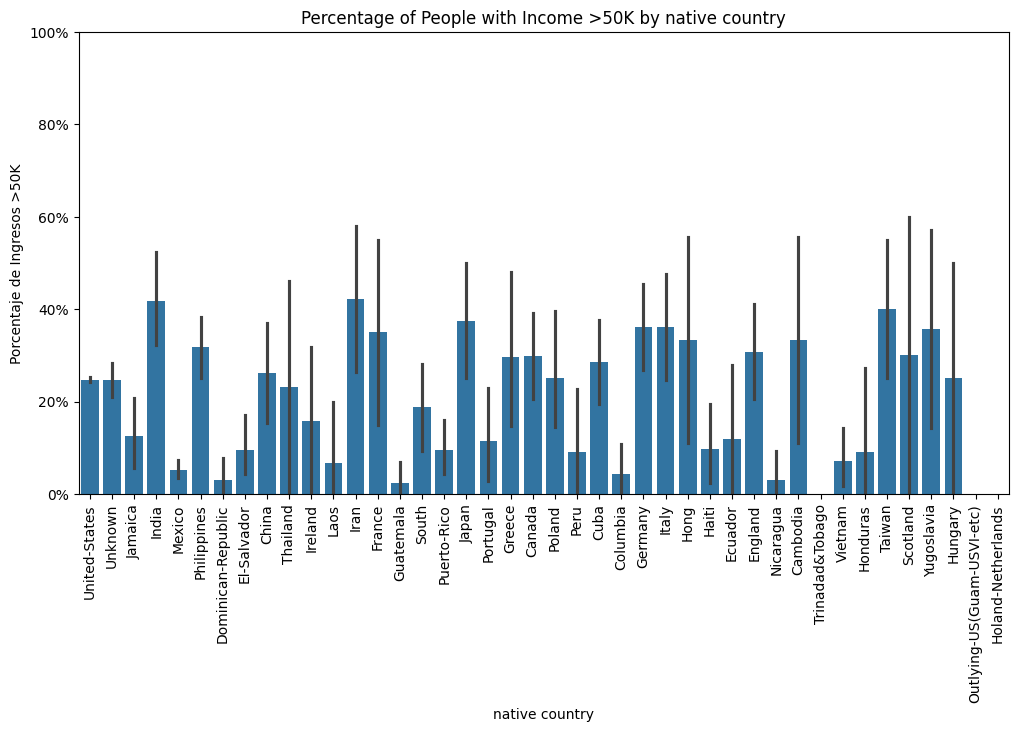

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(x='native.country', y='income_binary', data=df, errorbar=('ci', 95))
plt.xticks(rotation=90)
plt.title('Percentage of People with Income >50K by native country')
plt.xlabel('native country')
plt.ylim(0,1)
plt.ylabel('Porcentaje de Ingresos >50K')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
plt.show()

In [ ]:
stats = df.groupby('native.country')['income_binary'].agg(['mean', 'count']).copy()

stats['se'] = np.sqrt(stats['mean'] * (1 - stats['mean']) / stats['count'])

stats['lower_limit'] = stats['mean'] - 1.96 * stats['se']
stats['upper_limit'] = stats['mean'] + 1.96 * stats['se']

stats = stats.sort_values('mean', ascending=False)

print(stats[['mean', 'lower_limit', 'upper_limit']].map(lambda x: f"{x:.2%}"))

                              mean lower_limit upper_limit
native.country                                            
Iran                        42.11%      26.41%      57.80%
India                       41.67%      31.12%      52.21%
Taiwan                      40.00%      24.82%      55.18%
Japan                       37.50%      24.82%      50.18%
Germany                     36.11%      27.05%      45.17%
Italy                       36.07%      24.02%      48.12%
Yugoslavia                  35.71%      10.61%      60.81%
France                      35.00%      14.10%      55.90%
Hong                        33.33%      11.56%      55.11%
Cambodia                    33.33%      11.56%      55.11%
Philippines                 31.74%      24.68%      38.80%
England                     30.77%      20.53%      41.01%
Scotland                    30.00%       1.60%      58.40%
Canada                      29.90%      20.79%      39.01%
Greece                      29.63%      12.41%      46.8

In [ ]:
def preprocess_groupcountry(df):
  groupcountry_mapping = {
    'United-States':'United-States',
    'Jamaica': 'Other', 'India': 'Other',
    'Mexico': 'Other', 'Philippines': 'Other',
    'Dominican-Republic': 'Other',
    'El-Salvador' : 'Other',
    'China': 'Other',
    'Thailand' : 'Other',
    'Ireland' : 'Other',
    'Laos' : 'Other',
    'Iran' : 'Other',
    'France' : 'Other',
    'Guatemala' : 'Other',
    'South' : 'Other',
    'Puerto-Rico' : 'Other',
    'Japan': 'Other',
    'Portugal': 'Other',
    'Greece': 'Other',
    'Canada': 'Other',
    'Poland' : 'Other',
    'Peru' : 'Other',
    'Cuba': 'Other',
    'Columbia' : 'Other',
    'Germany': 'Other',
    'Italy' : 'Other', 'Hong': 'Other', 'Haiti': 'Other',
    'Ecuador': 'Other', 'England': 'Other', 'Nicaragua': 'Other', 'Cambodia': 'Other', 'Trinadad&Tobago': 'Other',
    'Vietnam': 'Other', 'Honduras': 'Other', 'Taiwan': 'Other', 'Scotland': 'Other', 'Yugoslavia': 'Other',
    'Unknown' : 'Other'
  }

  df = df.copy()
  df['native.country_grouped'] = df['native.country'].map(groupcountry_mapping)
  df.drop(columns='native.country', inplace=True)

  return df

In [ ]:
df = preprocess_groupcountry(df)

## 'Occupation'

The `occupation` variable showed strong heterogeneity in income proportions.
To reduce dimensionality (from 14 to 3 categories) and improve model stability,
occupations were grouped into tiers based on the proportion of individuals
earning >50K:

- **High Tier (~47%):** High-specialization and leadership roles such as
  `Exec-managerial` and `Prof-specialty`
- **Middle Tier (13%–32%):** Technical, sales, administrative, and skilled
  labor roles with intermediate income proportions
- **Low Tier / Unknown (<12%):** Manual, service-oriented occupations and
  unspecified records (`Unknown`), which exhibit consistently low income rates

This tier-based segmentation captures meaningful income patterns while reducing
sparsity.

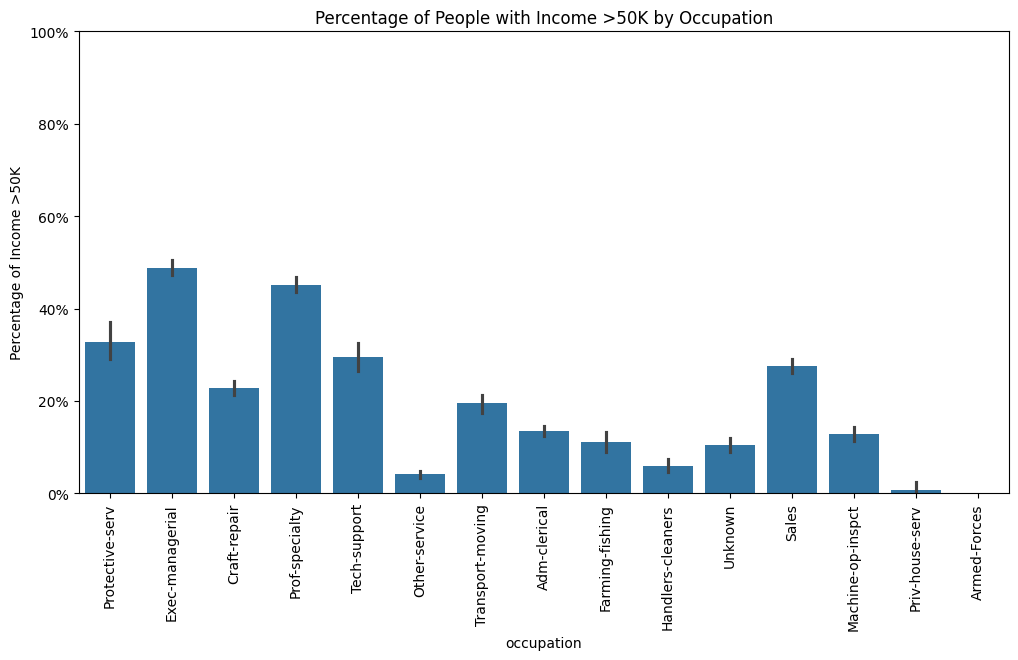

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(x='occupation', y='income_binary', data=df, errorbar=('ci', 95))
plt.xticks(rotation=90)
plt.title('Percentage of People with Income >50K by Occupation')
plt.xlabel('occupation')
plt.ylim(0,1)
plt.ylabel('Percentage of Income >50K')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
plt.show()

In [ ]:
stats = df.groupby('occupation')['income_binary'].agg(['mean', 'count']).copy()

stats['se'] = np.sqrt(stats['mean'] * (1 - stats['mean']) / stats['count'])

stats['lower_limit'] = stats['mean'] - 1.96 * stats['se']
stats['upper_limit'] = stats['mean'] + 1.96 * stats['se']

stats = stats.sort_values('mean', ascending=False)

print(stats[['mean', 'lower_limit', 'upper_limit']])

                       mean  lower_limit  upper_limit
occupation                                           
Exec-managerial    0.487826     0.471146     0.504506
Prof-specialty     0.451540     0.435144     0.467936
Protective-serv    0.328546     0.289539     0.367552
Tech-support       0.294654     0.262391     0.326918
Sales              0.275693     0.259873     0.291514
Craft-repair       0.228270     0.214383     0.242158
Transport-moving   0.195210     0.174283     0.216138
Adm-clerical       0.135310     0.123527     0.147094
Machine-op-inspct  0.128842     0.112878     0.144805
Farming-fishing    0.111372     0.090260     0.132484
Unknown            0.104787     0.089519     0.120054
Handlers-cleaners  0.060241     0.046560     0.073922
Other-service      0.041096     0.033709     0.048483
Priv-house-serv    0.008333    -0.007932     0.024598
Armed-Forces       0.000000     0.000000     0.000000


Occupation Management

Upon analyzing the occupation variable, significant heterogeneity in income rates was observed. To optimize predictive power and reduce dimensionality (consolidating 14 categories into 3), a tiered segmentation was implemented based on the proportion of individuals earning $>50K$:

- High Tier (~47% proportion): Includes highly specialized and leadership roles such as Exec-managerial and Prof-specialty. These categories serve as the strongest predictors of high income levels.

- Middle Tier (13% - 32% range): Groups technical, protective services, and administrative roles (Tech-support, Sales, Craft-repair, etc.). Despite the diversity within this group, its confidence intervals consistently remain in the intermediate range, clearly distinct from the extremes.

- Low Tier / Unknown (<12% range): Comprises operational, manual service, and unspecified occupations (Other-service, Farming-fishing, Handlers-cleaners, etc.). "Unknown" values were included in this group as their income profile statistically aligns with the lower-income categories.

In [ ]:
def preprocess_occupation(df):
  occupation_mapping = {

   'Exec-managerial':'high-tier',
    'Prof-specialty': 'high-tier',
    'Protective-serv': 'middle-tier',
  'Tech-support' :'middle-tier', 'Sales':'middle-tier',
    'Craft-repair': 'middle-tier', 'Transport-moving':'middle-tier', 'Adm-clerical':'middle-tier',
    'Machine-op-inspct': 'low_tier/unknown', 'farming-fishing' : 'low_tier/unknown', 'Handlers-cleaners' : 'low_tier/unknown', 'Other-service':'low_tier/unknown',
    'Priv-house-serv': 'low_tier/unknown',
    'Armed-Forces' : 'low_tier/unknown',
    'Unknown' : 'low_tier/unknown'
  }

  df = df.copy()
  df['occupation_grouped'] = df['occupation'].map(occupation_mapping)
  df.drop(columns='occupation', inplace=True)
  return df

In [ ]:
df = preprocess_occupation(df)

## 'Workclass'

### Workclass segmentation

Based on income rate analysis and confidence interval validation, the
`workclass` variable was structured into six statistically differentiated
categories:

- **Self-emp-inc (Premium – ~56%)**
- **Federal-gov (High Public Sector – ~38%)**
- **Mid-Tier (~28%):** `Local-gov`, `State-gov`, `Self-emp-not-inc`
- **Private (Baseline – ~21%)**
- **Unknown (~10%)**
- **Without Income (0%):** `Without-pay`, `Never-worked`

Categories were kept separate when confidence intervals showed no overlap and
consolidated otherwise, balancing interpretability and dimensionality reduction.

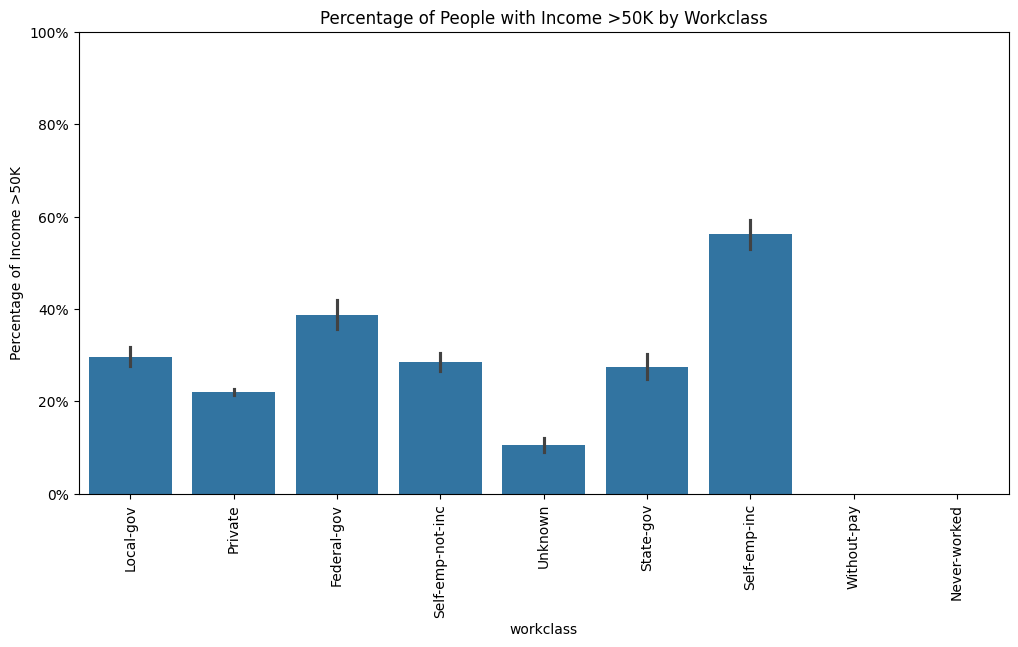

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(x='workclass', y='income_binary', data=df, errorbar=('ci', 95))
plt.xticks(rotation=90)
plt.title('Percentage of People with Income >50K by Workclass')
plt.xlabel('workclass')
plt.ylim(0,1)
plt.ylabel('Percentage of Income >50K')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
plt.show()

In [ ]:
stats = df.groupby('workclass')['income_binary'].agg(['mean', 'count']).copy()

stats['se'] = np.sqrt(stats['mean'] * (1 - stats['mean']) / stats['count'])

stats['lower_limit'] = stats['mean'] - 1.96 * stats['se']
stats['upper_limit'] = stats['mean'] + 1.96 * stats['se']

stats = stats.sort_values('mean', ascending=False)

print(stats[['mean', 'lower_limit', 'upper_limit']])

                      mean  lower_limit  upper_limit
workclass                                           
Self-emp-inc      0.561385     0.529880     0.592890
Federal-gov       0.388078     0.354764     0.421392
Local-gov         0.296778     0.275489     0.318067
Self-emp-not-inc  0.285250     0.266191     0.304310
State-gov         0.274843     0.248662     0.301024
Private           0.219928     0.214082     0.225775
Unknown           0.105263     0.089930     0.120596
Never-worked      0.000000     0.000000     0.000000
Without-pay       0.000000     0.000000     0.000000


In [ ]:
def preprocess_workclass(df):
  workclass_mapping = { 'Local-gov' : 'Mid-tier-workclass', 'Self-emp-not-inc' : 'Mid-tier-workclass',
                     'State-gov' : 'Mid-tier-workclass', 'Never-worked' : 'Without-income',
                      'Without-pay' : 'Without-income', 'Private' : 'Private',
                      'Self-emp-inc' : 'Self-emp-inc', 'Federal-gov': 'Federal-gov',
                      'Unknown' : 'Unknown'
                 }

  df = df.copy()
  df['workclass_grouped'] = df['workclass'].map(workclass_mapping)
  df.drop(columns='workclass', inplace=True)
  return df

In [ ]:
df = preprocess_workclass(df)

## 'Race'

### Demographic Representation Segmentation.

Based on income proportion analysis and confidence interval validation, a clear
polarization was identified in the `race` variable. The feature was binarized
according to target behavior:

- **Segment I (Higher Income Representation):** `White` and
  `Asian-Pac-Islander`. Both groups show similar >50K income proportions
  (~25–26%) with overlapping confidence intervals, indicating comparable
  behavior with respect to the target.

- **Segment II (Lower Income Representation):** `Black`,
  `Amer-Indian-Eskimo`, and `Other`. These categories exhibit consistently lower
  income proportions. Due to their lower individual frequency, consolidation
  helps stabilize model variance and reduce noise.

In [ ]:
df['race'].describe()

,race
count,27656
unique,5
top,White
freq,23621


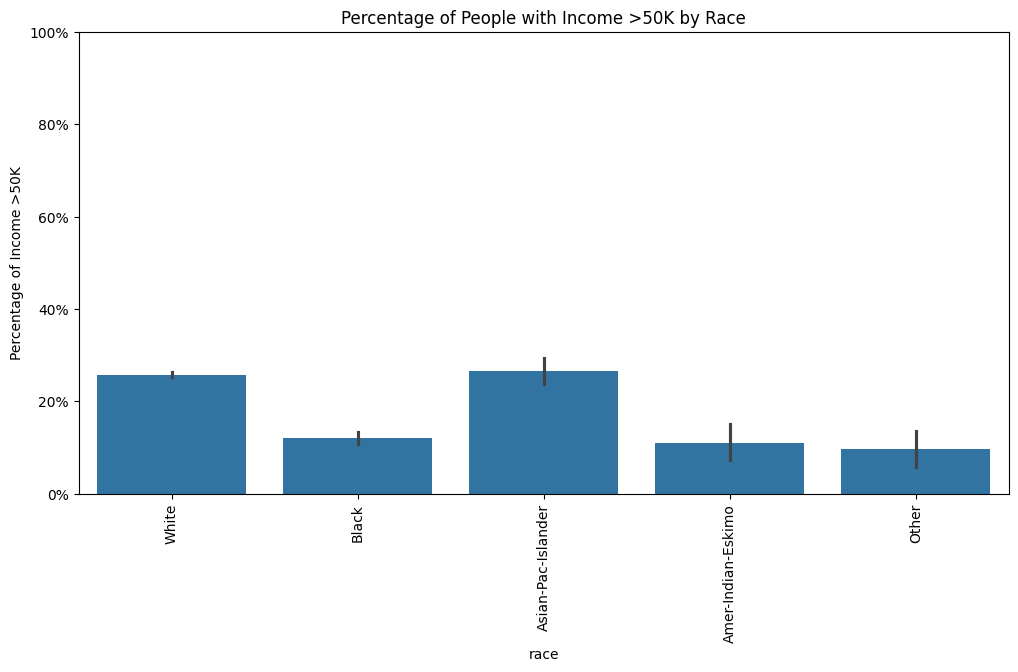

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(x='race', y='income_binary', data=df, errorbar=('ci', 95))
plt.xticks(rotation=90)
plt.title('Percentage of People with Income >50K by Race')
plt.xlabel('race')
plt.ylim(0,1)
plt.ylabel('Percentage of Income >50K')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
plt.show()

In [ ]:
stats = df.groupby('race')['income_binary'].agg(['mean', 'count']).copy()

stats['se'] = np.sqrt(stats['mean'] * (1 - stats['mean']) / stats['count'])

stats['lower_limit'] = stats['mean'] - 1.96 * stats['se']
stats['upper_limit'] = stats['mean'] + 1.96 * stats['se']

stats = stats.sort_values('mean', ascending=False)

print(stats[['mean', 'lower_limit', 'upper_limit']])

                        mean  lower_limit  upper_limit
race                                                  
Asian-Pac-Islander  0.265237     0.236168     0.294306
White               0.258033     0.252453     0.263613
Black               0.121178     0.108750     0.133605
Amer-Indian-Eskimo  0.110266     0.072411     0.148122
Other               0.097046     0.059358     0.134735


In [ ]:
def preprocess_race(df):
  race_mapping = {
     'Asian-Pac-Islander': 'Segmento I', 'White': 'Segmento I',
      'Black' : 'Segmento II' , 'Amer-Indian-Eskimo': 'Segmento II', 'Other': 'Segmento II'
}

  df = df.copy()
  df['race_grouped'] = df['race'].map(race_mapping)
  df.drop(columns='race', inplace=True)
  return df

In [ ]:
df = preprocess_race(df)

We drop the columns that are not necessary for the training set and might cause confusion to the model.

In [ ]:
df.drop(columns=['ID', 'index'], inplace=True)

###  Categorical Correlation Analysis (Cramér’s V)

### Before Preprocessing
- `relationship` & `marital.status`: 0.49  
- `sex` & `marital.status`: 0.46  
- Both `marital.status` and `relationship` show moderate correlation
  (~0.45) with the target variable (`income`)
- The strongest association was observed between `sex` & `relationship` (0.65)

### After Preprocessing
After category consolidation and cardinality reduction:

- `relationship_grouped` & `marital_grouped` show near-perfect correlation,
  indicating multicollinearity and suggesting that one of these features could
  be removed
- Correlation between `sex` and `relationship` decreased from 0.65 to ~0.45,
  indicating reduced redundancy and improved feature independence


In [ ]:
from scipy.stats import chi2_contingency

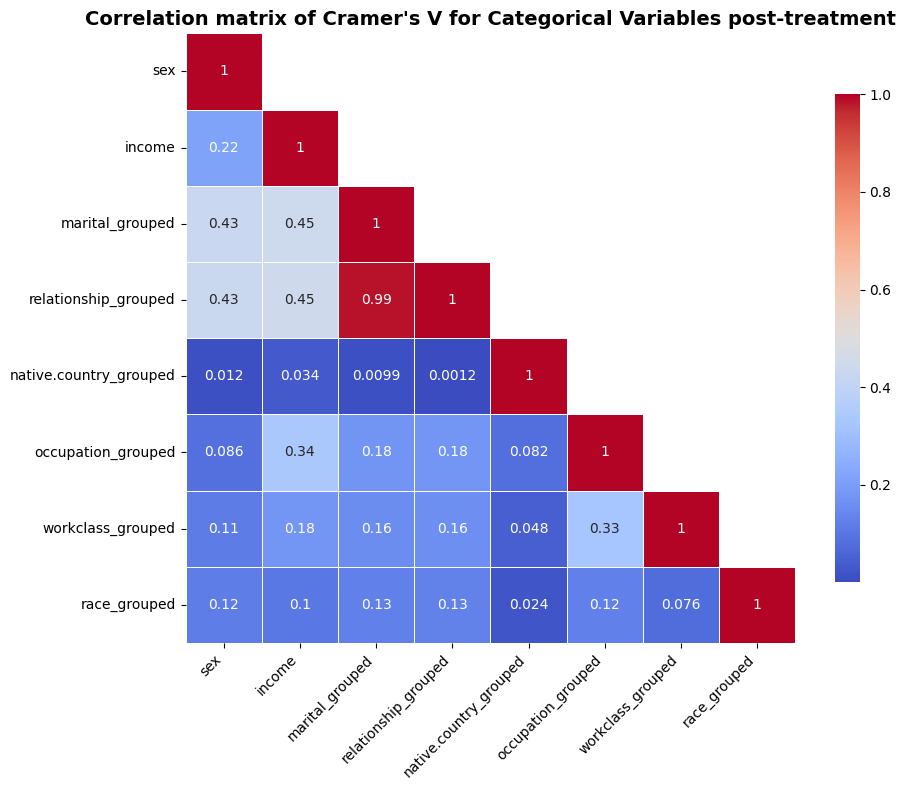

In [ ]:
def cramers_v(x ,y):
  contingency_table = pd.crosstab(x,y)
  chi2, __, __, _ = chi2_contingency(contingency_table)
  n = contingency_table.sum().sum()
  return np.sqrt(chi2 / (n * (min(contingency_table.shape) - 1)))

categoricas = df.select_dtypes(include=['object']).columns

cramers_v_matrix = pd.DataFrame(np.zeros((len(categoricas), len(categoricas))), columns=categoricas, index=categoricas)

for col1 in categoricas:
  for col2 in categoricas:
    cramers_v_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])

mask = np.triu(np.ones_like(cramers_v_matrix, dtype=bool), k=1)

plt.figure(figsize=(10,8))
ax = sns.heatmap(cramers_v_matrix.astype(float), annot=True, cmap='coolwarm', square=True, linewidths=0.5, cbar_kws={"shrink": .8}, mask=mask)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.title("Correlation matrix of Cramer's V for Categorical Variables post-treatment", fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

### Numerical Correlation Analysis (Pearson)

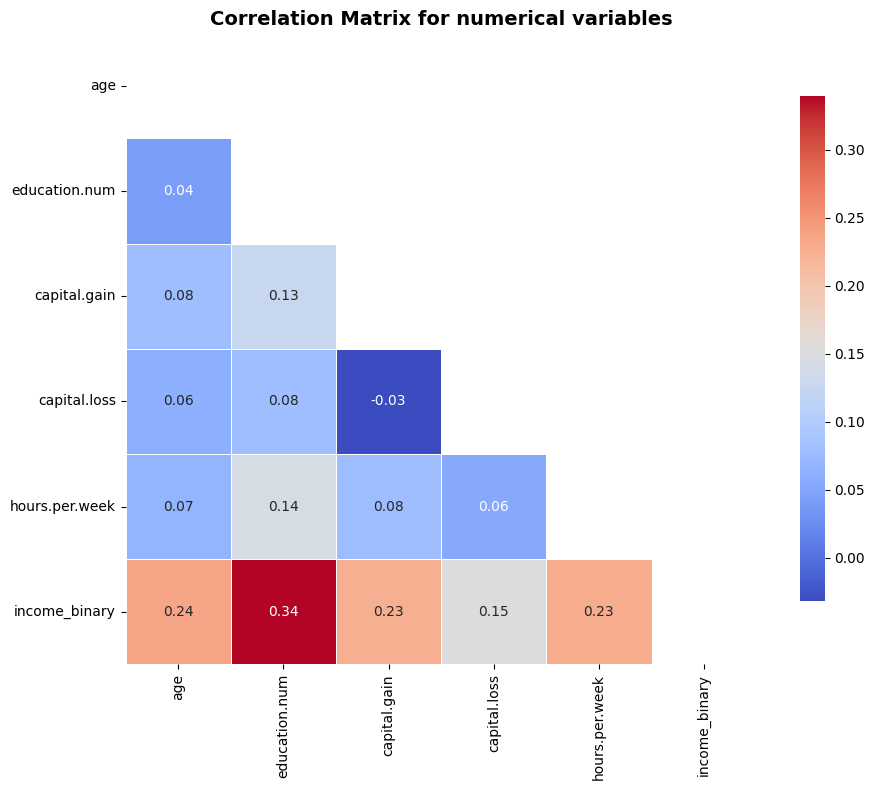

In [ ]:
df_corr = df.copy()
numericas_con_target = df_corr.select_dtypes(include=['int64', 'float64'])
corr = numericas_con_target.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", mask=mask, square=True, linewidths=0.5, cbar_kws={"shrink": .8})
plt.title("Correlation Matrix for numerical variables", fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

# Model Development and Evaluation

The modeling phase was structured into a systematic pipeline to ensure reproducibility and prevent data leakage. The process followed these key stages:

1. **Feature and Target Separation: **The dataset was partitioned into the feature matrix ($X$), containing the demographic and employment predictors, and the target vector ($y$), representing the binary income classification ($>50K$ or $\leq50K$).

2. **Train-Test Split:** To evaluate the model's ability to generalize to unseen data, the dataset was split into training and testing sets (typically using an 80/20 or 70/30 ratio). This separation is crucial for validating performance and detecting potential overfitting.

3. **Categorical Variable Encoding (One-Hot Encoding)**: Following the manual tier-based grouping performed during the EDA, the remaining categorical variables were transformed using One-Hot Encoding. This process converts nominal categories into binary numerical vectors, allowing the algorithms to process them mathematically without implying an artificial ordinal relationship.

4. **Model Training:** Multiple algorithms were implemented and trained using the training partition. This stage focused on fitting the models to the underlying patterns of the "Adult" dataset, utilizing the simplified feature set derived from the previous parsimony-driven engineering steps.

5. **Performance Metrics:** Evaluation Model performance was assessed using the test set through a comprehensive suite of metrics. Beyond simple Accuracy, the evaluation focused on:

- **Precision and Recall:** To understand the trade-off in classifying high-income earners.
- **F1-Score:** To provide a balanced measure of the model's harmonic mean between precision and recall.
- **ROC-AUC**: To measure the model's ability to distinguish between classes across different thresholds.

### Target and predictors split




In [ ]:
X = df.drop(['income_binary', 'income'], axis=1)
y = df['income_binary']

### Train test split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

`Stratify y `= good practice for imbalanced classes.

### Categorical variable Encoding

In [ ]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='if_binary')

In [ ]:
nominals_columns = X_train.select_dtypes(include='object').columns.tolist()
numeric_columns = X_train.select_dtypes(include=['int', 'float']).columns.tolist()

In [ ]:
#column selection
nominals_columns, numeric_columns

(['sex',
  'marital_grouped',
  'relationship_grouped',
  'native.country_grouped',
  'occupation_grouped',
  'workclass_grouped',
  'race_grouped'],
 ['age', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week'])

In [ ]:
# Fit OneHotEncoder on X_train's categorical columns
ohe.fit(X_train[nominals_columns])
X_train_cat_encoded = ohe.transform(X_train[nominals_columns])

In [ ]:
encoded_cols = ohe.get_feature_names_out(nominals_columns)

# Create DataFrames for encoded categorical features for X_train
X_train_cat_encoded_df = pd.DataFrame(X_train_cat_encoded, columns=encoded_cols, index=X_train.index)

# Transform X_test using the encoder fitted on X_train
X_test_cat_encoded = ohe.transform(X_test[nominals_columns])
X_test_cat_encoded_df = pd.DataFrame(X_test_cat_encoded, columns=encoded_cols, index=X_test.index)

In [ ]:
# Concatenate numerical and encoded categorical features for X_train, dropping original categorical columns
X_train = pd.concat([X_train[numeric_columns], X_train_cat_encoded_df], axis=1)
X_train = X_train.drop(columns=nominals_columns, errors='ignore')

In [ ]:
# Concatenate numerical and encoded categorical features for X_test, dropping original categorical columns
X_test = pd.concat([X_test[numeric_columns], X_test_cat_encoded_df], axis=1)
X_test = X_test.drop(columns=nominals_columns, errors='ignore')

In [ ]:
print('X_train info:')
X_train.info()

X_train info:
<class 'pandas.core.frame.DataFrame'>
Index: 22124 entries, 8591 to 22737
Data columns (total 22 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   age                                   22124 non-null  int64  
 1   education.num                         22124 non-null  int64  
 2   capital.gain                          22124 non-null  int64  
 3   capital.loss                          22124 non-null  int64  
 4   hours.per.week                        22124 non-null  int64  
 5   sex_Male                              22124 non-null  float64
 6   marital_grouped_Married               22124 non-null  float64
 7   relationship_grouped_Partner          22124 non-null  float64
 8   native.country_grouped_Other          22124 non-null  float64
 9   native.country_grouped_United-States  22124 non-null  float64
 10  native.country_grouped_nan            22124 non-null  float64
 11  occ

In [ ]:
print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('\nX_train info:')
X_train.info()

X_train shape: (22124, 22)
X_test shape: (5532, 22)

X_train info:
<class 'pandas.core.frame.DataFrame'>
Index: 22124 entries, 8591 to 22737
Data columns (total 22 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   age                                   22124 non-null  int64  
 1   education.num                         22124 non-null  int64  
 2   capital.gain                          22124 non-null  int64  
 3   capital.loss                          22124 non-null  int64  
 4   hours.per.week                        22124 non-null  int64  
 5   sex_Male                              22124 non-null  float64
 6   marital_grouped_Married               22124 non-null  float64
 7   relationship_grouped_Partner          22124 non-null  float64
 8   native.country_grouped_Other          22124 non-null  float64
 9   native.country_grouped_United-States  22124 non-null  float64
 10  native.country_gr

In [ ]:
print('\nX_test info:')
X_test.info()


X_test info:
<class 'pandas.core.frame.DataFrame'>
Index: 5532 entries, 928 to 7552
Data columns (total 22 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   age                                   5532 non-null   int64  
 1   education.num                         5532 non-null   int64  
 2   capital.gain                          5532 non-null   int64  
 3   capital.loss                          5532 non-null   int64  
 4   hours.per.week                        5532 non-null   int64  
 5   sex_Male                              5532 non-null   float64
 6   marital_grouped_Married               5532 non-null   float64
 7   relationship_grouped_Partner          5532 non-null   float64
 8   native.country_grouped_Other          5532 non-null   float64
 9   native.country_grouped_United-States  5532 non-null   float64
 10  native.country_grouped_nan            5532 non-null   float64
 11  occupa

In this way, only the binary columns remain, where the rows represent the category of the column with a 1 and the other absent category with a 0.

# 5. Model Selection

We are going to train a Random Forest algorithm.
We start with the training set X_train, y_train.

## RandomForestClassifier.

The hyperparameters will be as follows:

- max_depth=10
- n_estimators=200
- n_jobs=-1
- random_state=0

In [ ]:
from sklearn.ensemble import RandomForestClassifier

We will use the class_weight='balanced' parameter because of our imbalanced target.

In [ ]:
rf_clf = RandomForestClassifier(max_depth=10, n_estimators=200, n_jobs=-1, random_state=0, class_weight='balanced')

In [ ]:
rf_clf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       n_jobs=-1, random_state=0)

We now make the predictions:

In [ ]:
train_pred = rf_clf.predict(X_train)

In [ ]:
test_pred= rf_clf.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
print('metrics in train')
print(classification_report(y_train, train_pred))
print('metrics in test')
print(classification_report(y_test, test_pred))

metrics in train
              precision    recall  f1-score   support

           0       0.96      0.81      0.88     16762
           1       0.60      0.89      0.72      5362

    accuracy                           0.83     22124
   macro avg       0.78      0.85      0.80     22124
weighted avg       0.87      0.83      0.84     22124

metrics in test
              precision    recall  f1-score   support

           0       0.94      0.80      0.87      4191
           1       0.58      0.85      0.69      1341

    accuracy                           0.82      5532
   macro avg       0.76      0.83      0.78      5532
weighted avg       0.86      0.82      0.83      5532



### Confusion Matrix

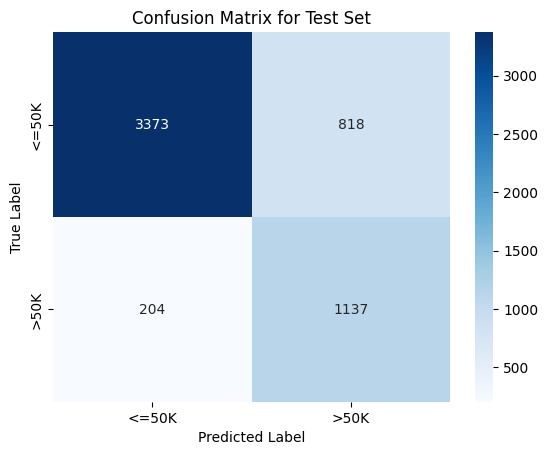

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'])
plt.title('Confusion Matrix for Test Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## **Model Performance Analysis**

The Random Forest model demonstrates robust performance, maintaining a consistent balance between learning the training patterns and generalizing to new data.

## Generalization and Stability

The model achieved an Accuracy of 82% on the test set, closely mirroring the 83% training accuracy. This minimal delta suggests a high degree of generalization and confirms that the feature engineering (grouping tiers for occupation, workclass, etc.) successfully mitigated overfitting.

## The Impact of Class Weighting

Given the inherent class imbalance ($\approx 75\%$ earning $\leq50K$), the use of `class_weight='balanced'` was pivotal. Without this adjustment, the model would likely have become a "majority-class classifier." Instead, we successfully forced the model to prioritize the minority class ($>50K$), resulting in the following dynamics:

----

### Metric Deep Dive:

The Precision-Recall Trade-offFor the minority class (Income >50K), the results reveal a specific strategic profile:Sensitivity (Recall) of 0.85: The model is exceptionally good at "finding" high-income earners. It successfully captures 85% of the total $>50K$ population.Precision of 0.58: The cost of this high sensitivity is a higher rate of False Positives. When the model flags an individual as high-income, there is a 42% chance they actually earn $\leq50K$.Statistical Note: The F1-Score for the minority class ($0.69$) is calculated as the harmonic mean:
$$F1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

This score reflects a model that prefers inclusion over exclusion.

## **Business & Practical Application**

In a real-world scenario (such as a premium credit card marketing campaign), this model's profile is highly advantageous:

- The "Wide Net" Strategy: For a business, the cost of missing a high-value customer (False Negative) is usually much higher than the cost of sending a brochure to someone who doesn't qualify (False Positive).

- Efficiency: While the precision is 58%, this is still 2.4 times better than random guessing (which would only be 24% accurate for this class). The model significantly optimizes the marketing budget by narrowing the target pool while ensuring that 85% of the potential market is reached.

---

## **Final Verdict:**

The model is highly effective for discovery-driven tasks. While it could be refined further to reduce false positives (e.g., through hyperparameter tuning of the min_samples_leaf or max_features), its current ability to recover the vast majority of the minority class makes it a powerful tool for proactive decision-making.

### Next step is to evaluate feature importances:

In [ ]:
rf_clf.feature_importances_

array([1.06025010e-01, 1.16814174e-01, 1.19886883e-01, 3.23908938e-02,
       5.07061300e-02, 2.34268232e-02, 1.93233289e-01, 2.11312651e-01,
       2.42699894e-03, 2.57417527e-03, 1.44028990e-04, 6.58919767e-02,
       3.54093692e-02, 1.31825607e-02, 5.69960694e-03, 2.28527578e-03,
       4.33976521e-03, 3.22440931e-03, 4.20287177e-03, 1.61055621e-03,
       9.49256732e-05, 5.11762524e-03])

In [ ]:
fi = pd.DataFrame(columns=["FEATURE", "IMPORTANCE"])

In [ ]:
fi["FEATURE"] = X_train.columns
fi["IMPORTANCE"] = rf_clf.feature_importances_

In [ ]:
fi.sort_values("IMPORTANCE", ascending=False, inplace=True)

In [ ]:
fi

,FEATURE,IMPORTANCE
7,relationship_grouped_Partner,0.211313
6,marital_grouped_Married,0.193233
2,capital.gain,0.119887
1,education.num,0.116814
0,age,0.106025
11,occupation_grouped_high-tier,0.065892
4,hours.per.week,0.050706
12,occupation_grouped_low_tier/unknown,0.035409
3,capital.loss,0.032391
5,sex_Male,0.023427


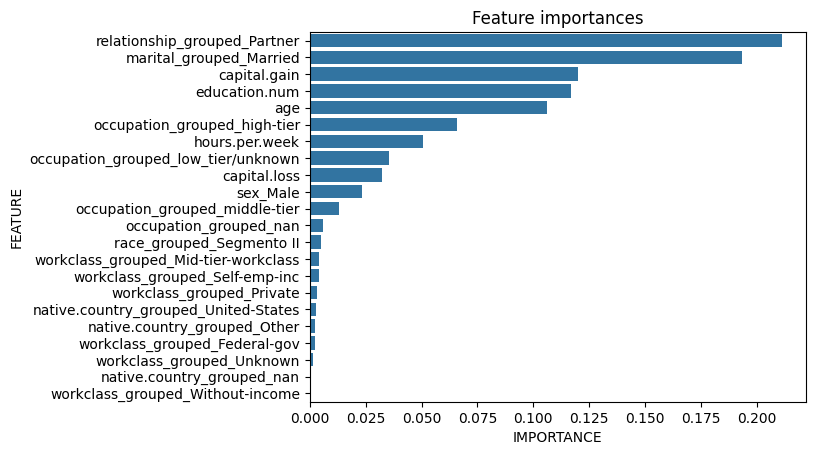

In [ ]:
sns.barplot(x=fi['IMPORTANCE'], y=fi['FEATURE'])
plt.title(label='Feature importances')
plt.show()

### **Feature Importance Analysis**

The Random Forest model identifies household stability and socio-demographic maturity as the primary drivers of high income. The top predictors are:

- The Partnership Signal (~40% cumulative weight): `relationship_grouped_Partner `and `marital_grouped_Married` dominate the model's decision-making. This reflects a strong historical correlation in the census data between stable, dual-income, or established households and higher economic brackets.

- Economic Indicators: `capital.gain` ranks as the third most influential feature. This aligns with economic logic, as capital investments are direct proxies for accumulated wealth and high-tier income status.

- Human Capital Foundation: `education.num` and `age` provide the baseline for earnings, representing the formal training and professional seniority required to reach the >50K threshold.

**Conclusion:** The model relies on robust, non-volatile features, which explains the high generalization (82% test accuracy) and the lack of overfitting.

## Inference on Unlabeled Test Data

The model was deployed to predict income classes for a blind test set (unlabeled data). This simulates a real-world production scenario where the model must classify new individuals without knowing the actual outcome.

1. Loading the Test Dataset
This dataset contains records that were never seen by the algorithm during the training or hyperparameter tuning phases.

In [ ]:
df_predict = pd.read_csv('/content/sample_data/test.csv')
ids_test = df_predict['ID']

print("Original shape of df_predict:", df_predict.shape)

Original shape of df_predict: (4881, 15)


2. Preprocessing Pipeline Consistency

To maintain data integrity, the exact same transformations performed on the training set were applied to the test set:

- Missing Value Handling: Identifying and managing "Unknown" or ? records.

- Tiered Grouping: Consolidating categories for Occupation, Workclass, and Relationship into their respective hierarchical levels.

- Encoding & Alignment: Applying One-Hot Encoding and ensuring the feature columns align perfectly with the training matrix (X_train).

In [ ]:
df_predict.replace('?', 'Unknown', inplace=True)

df_predict.drop(columns=['ID', 'index'], inplace=True, errors='ignore')

df_predict.drop(columns=['education'], inplace=True, errors='ignore')

#reducing categorical variables cardinality
df_predict = preprocess_marital_status(df_predict)
df_predict = preprocess_relationship(df_predict)
df_predict = preprocess_groupcountry(df_predict)
df_predict = preprocess_occupation(df_predict)
df_predict = preprocess_workclass(df_predict)
df_predict = preprocess_race(df_predict)

print("df_predict después de la ingeniería de características:")
df_predict.info()

df_predict después de la ingeniería de características:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4881 entries, 0 to 4880
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   age                     4881 non-null   int64 
 1   education.num           4881 non-null   int64 
 2   sex                     4881 non-null   object
 3   capital.gain            4881 non-null   int64 
 4   capital.loss            4881 non-null   int64 
 5   hours.per.week          4881 non-null   int64 
 6   marital_grouped         4881 non-null   object
 7   relationship_grouped    4881 non-null   object
 8   native.country_grouped  4877 non-null   object
 9   occupation_grouped      4742 non-null   object
 10  workclass_grouped       4881 non-null   object
 11  race_grouped            4881 non-null   object
dtypes: int64(5), object(7)
memory usage: 457.7+ KB


In [ ]:
df_predict

,age,education.num,sex,capital.gain,capital.loss,hours.per.week,marital_grouped,relationship_grouped,native.country_grouped,occupation_grouped,workclass_grouped,race_grouped
0,53,10,Male,3137,0,40,Married,Partner,United-States,low_tier/unknown,Private,Segmento I
1,18,7,Male,0,0,25,Alone,Other,United-States,low_tier/unknown,Unknown,Segmento I
2,42,10,Female,0,0,37,Married,Partner,United-States,low_tier/unknown,Private,Segmento I
3,49,16,Male,0,0,60,Married,Partner,United-States,high-tier,Self-emp-inc,Segmento II
4,58,13,Female,0,0,40,Married,Partner,United-States,high-tier,Mid-tier-workclass,Segmento I
...,...,...,...,...,...,...,...,...,...,...,...,...
4876,50,9,Female,0,0,40,Alone,Other,United-States,middle-tier,Private,Segmento I
4877,43,13,Male,0,0,40,Married,Partner,United-States,middle-tier,Mid-tier-workclass,Segmento I
4878,71,11,Female,0,0,40,Alone,Other,United-States,middle-tier,Private,Segmento I
4879,20,10,Male,0,0,40,Alone,Other,Other,middle-tier,Private,Segmento I


One-Hot Encoding preprocessing

In [ ]:
nominal_cols_to_transform_predict = [col for col in nominals_columns if col in df_predict.columns]

X_predict_cat_encoded = ohe.transform(df_predict[nominal_cols_to_transform_predict])
X_predict_cat_encoded_df = pd.DataFrame(X_predict_cat_encoded, columns=encoded_cols, index=df_predict.index)

numeric_cols_predict = [col for col in df_predict.columns if col not in nominal_cols_to_transform_predict]

X_predict = pd.concat([df_predict[numeric_cols_predict], X_predict_cat_encoded_df], axis=1)

print("X_predict shape after One-Hot Encoding:", X_predict.shape)
print("X_predict info after One-Hot Encoding:")
X_predict.info()

X_predict shape after One-Hot Encoding: (4881, 22)
X_predict info after One-Hot Encoding:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4881 entries, 0 to 4880
Data columns (total 22 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   age                                   4881 non-null   int64  
 1   education.num                         4881 non-null   int64  
 2   capital.gain                          4881 non-null   int64  
 3   capital.loss                          4881 non-null   int64  
 4   hours.per.week                        4881 non-null   int64  
 5   sex_Male                              4881 non-null   float64
 6   marital_grouped_Married               4881 non-null   float64
 7   relationship_grouped_Partner          4881 non-null   float64
 8   native.country_grouped_Other          4881 non-null   float64
 9   native.country_grouped_United-States  4881 non-null   float64

Ensure that the columns in X_predict match those in X_train.

In [ ]:
missing_cols_in_predict = set(X_train.columns) - set(X_predict.columns)
for c in missing_cols_in_predict:
    X_predict[c] = 0

extra_cols_in_predict = set(X_predict.columns) - set(X_train.columns)
X_predict.drop(columns=list(extra_cols_in_predict), inplace=True)

X_predict = X_predict[X_train.columns]

print("X_predict final shape (aligned with X_train):", X_predict.shape)
print("X_predict columns aligned:\n", X_predict.columns.tolist())

X_predict final shape (aligned with X_train): (4881, 22)
X_predict columns aligned:
 ['age', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week', 'sex_Male', 'marital_grouped_Married', 'relationship_grouped_Partner', 'native.country_grouped_Other', 'native.country_grouped_United-States', 'native.country_grouped_nan', 'occupation_grouped_high-tier', 'occupation_grouped_low_tier/unknown', 'occupation_grouped_middle-tier', 'occupation_grouped_nan', 'workclass_grouped_Federal-gov', 'workclass_grouped_Mid-tier-workclass', 'workclass_grouped_Private', 'workclass_grouped_Self-emp-inc', 'workclass_grouped_Unknown', 'workclass_grouped_Without-income', 'race_grouped_Segmento II']


3. Model Inference

The trained Random Forest model was used to predict the income class for the test set. By comparing these predictions against the actual ground truth labels, we can determine the model's reliability in a production-like environment.

In [ ]:
predictions = rf_clf.predict(X_predict)

print("Generated predictions:", predictions[:10])

Generated predictions: [0 0 0 1 1 0 0 0 0 0]


2. Prediction Distribution Analysis

Since ground truth labels are unavailable for this specific dataset, we analyzed the distribution of the predictions.

Finding: The model classified approximately 33.97%% of the individuals as high-income ($>50K$) and 66.03% as $\leq50K$.

Consistency Check: This distribution was compared against the training set to ensure the model isn't making biased or "extreme" predictions on the new data.

In [ ]:
rf_clf.predict_proba(X_predict)

array([[0.51138911, 0.48861089],
       [0.99582382, 0.00417618],
       [0.50474428, 0.49525572],
       ...,
       [0.91514349, 0.08485651],
       [0.97752927, 0.02247073],
       [0.75006611, 0.24993389]])

--- Distribution of Predictions ---
Class <=50K: 3223 individuals (66.03%)
Class >50K: 1658 individuals (33.97%)


/tmp/ipython-input-4235758537.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[">50K", "<=50K"], y=[prediction_pct[1], prediction_pct[0]], palette='viridis')


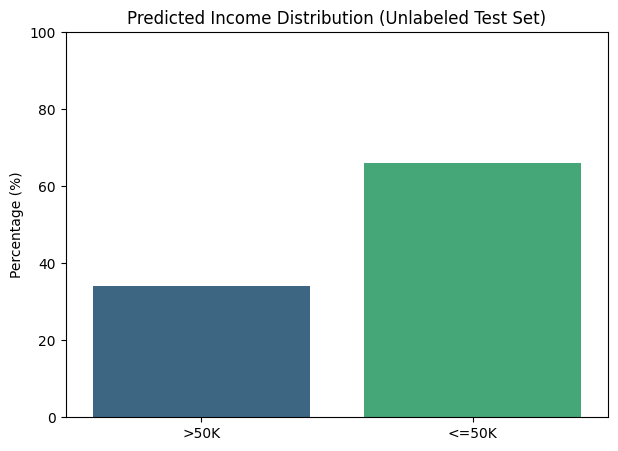

In [ ]:
prediction_counts = pd.Series(predictions).value_counts()
prediction_pct = pd.Series(predictions).value_counts(normalize=True) * 100

print("--- Distribution of Predictions ---")
for label, pct in prediction_pct.items():
    class_name = ">50K" if label == 1 else "<=50K"
    count = prediction_counts[label]
    print(f"Class {class_name}: {count} individuals ({pct:.2f}%)")

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))
sns.barplot(x=[">50K", "<=50K"], y=[prediction_pct[1], prediction_pct[0]], palette='viridis')
plt.title('Predicted Income Distribution (Unlabeled Test Set)')
plt.ylabel('Percentage (%)')
plt.ylim(0, 100)
plt.show()

3. Lead Generation / Actionable Output

The final output of this stage is a new CSV file containing the original features paired with the model's predicted label and its ID. In a business context, these individuals would be passed to the marketing or sales department as "High-Potential Leads."

In [ ]:
submission_df = pd.DataFrame({'ID': ids_test, 'PRED': predictions})

submission_df['PRED'] = submission_df['PRED'].map({1: '>50K', 0: '<=50K'})

submission_df.to_csv('submission.csv', index=False)

print("File: 'submission.csv' succesfully created!.")
print("First 5 rows of the submission file:\n", submission_df.head())

File: 'submission.csv' succesfully created!.
First 5 rows of the submission file:
       ID   PRED
0   3643  <=50K
1  16036  <=50K
2   9401  <=50K
3  17903   >50K
4   5198   >50K


--------
Author: Paloma Perez Valdenegro
-------